# Neural Networks: AND Gate (NumPy) & Fitness Classification (Keras)

In [4]:
%pip install numpy matplotlib tensorflow scikit-learn pandas -q

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Part 1: AND Gate — Neural Network from Scratch

In [5]:
X_and = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([[0],[0],[0],[1]])

np.random.seed(42)
W1 = np.random.randn(2, 4)
b1 = np.zeros((1, 4))
W2 = np.random.randn(4, 1)
b2 = np.zeros((1, 1))

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

lr = 0.1
losses = []

for _ in range(5500):
    a1 = sigmoid(X_and @ W1 + b1)
    a2 = sigmoid(a1 @ W2 + b2)

    loss = np.mean((a2 - y_and) ** 2)
    losses.append(loss)

    dz2 = 2 * (a2 - y_and) / len(y_and) * a2 * (1 - a2)
    dz1 = (dz2 @ W2.T) * a1 * (1 - a1)
    W2 -= lr * a1.T @ dz2
    b2 -= lr * np.sum(dz2, axis=0, keepdims=True)
    W1 -= lr * X_and.T @ dz1
    b1 -= lr * np.sum(dz1, axis=0, keepdims=True)

print('Final MSE Loss:', round(losses[-1], 6))
print('Predictions:', a2.round().flatten())
print('Actual:     ', y_and.flatten())


Final MSE Loss: 0.005391
Predictions: [0. 0. 0. 1.]
Actual:      [0 0 0 1]


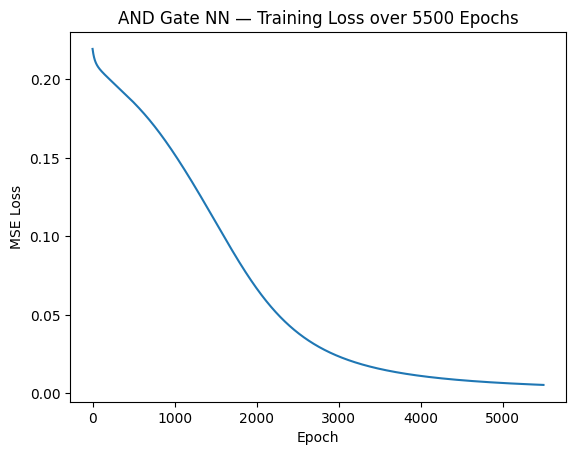

In [6]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('AND Gate NN — Training Loss over 5500 Epochs')
plt.show()

## Part 2: Fitness Classification (Keras)

In [7]:
df = pd.read_csv('fitness_dataset.csv')

df['sleep_hours'] = df['sleep_hours'].fillna(df['sleep_hours'].median())
df['smokes'] = df['smokes'].astype(str).str.lower().isin(['yes', '1', 'true']).astype(int)
df['gender'] = (df['gender'] == 'M').astype(int)

X = df.drop(columns=['is_fit']).values
y = df['is_fit'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=0)

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Accuracy: {acc:.4f}')
print(f'Test Loss:     {loss:.4f}')

d:\Data\Github\SheldonC2005\Academics\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Accuracy: 0.7775
Test Loss:     0.5317


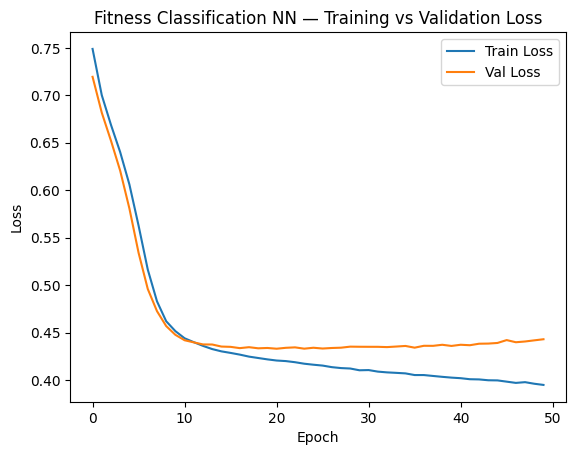

In [9]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fitness Classification NN — Training vs Validation Loss')
plt.legend()
plt.show()